<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Chess_Player_Rating_Change_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Step 1: Import Libraries & Upload Data



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# For uploading CSV file from your local system
from google.colab import files
uploaded = files.upload()

# Load the CSV file
filename = next(iter(uploaded))
df = pd.read_csv(filename)
df.head()



Saving games.csv to games (4).csv


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


✅ Step 2: Convert Timestamps to Readable Dates

In [12]:
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')


✅ Step 3: Build Player Rating Timeline


In [13]:
# White player games
white_games = df[['white_id', 'white_rating', 'created_at']].copy()
white_games.columns = ['player_id', 'rating', 'date']

# Black player games
black_games = df[['black_id', 'black_rating', 'created_at']].copy()
black_games.columns = ['player_id', 'rating', 'date']

# Combine all games
all_games = pd.concat([white_games, black_games])
all_games.sort_values(by=['player_id', 'date'], inplace=True)


✅ Step 4: Compute Rating Change Per Player

In [14]:
# Calculate rating change between successive games
all_games['rating_diff'] = all_games.groupby('player_id')['rating'].diff()

# Drop NaNs (first game has no diff)
rating_changes = all_games.dropna()


✅ Step 5: Clean and Filter Outliers


In [15]:
# Keep changes within a reasonable range
rating_changes = rating_changes[np.abs(rating_changes['rating_diff']) < 200]


✅ Step 6: Visualize Rating Changes



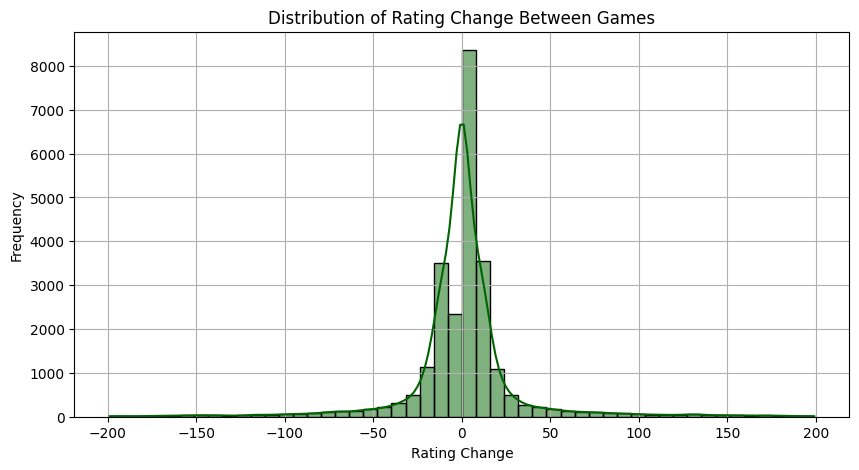

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(rating_changes['rating_diff'], bins=50, kde=True, color='darkgreen')
plt.title("Distribution of Rating Change Between Games")
plt.xlabel("Rating Change")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


✅ Step 7: Sample Rating Evolution Plot

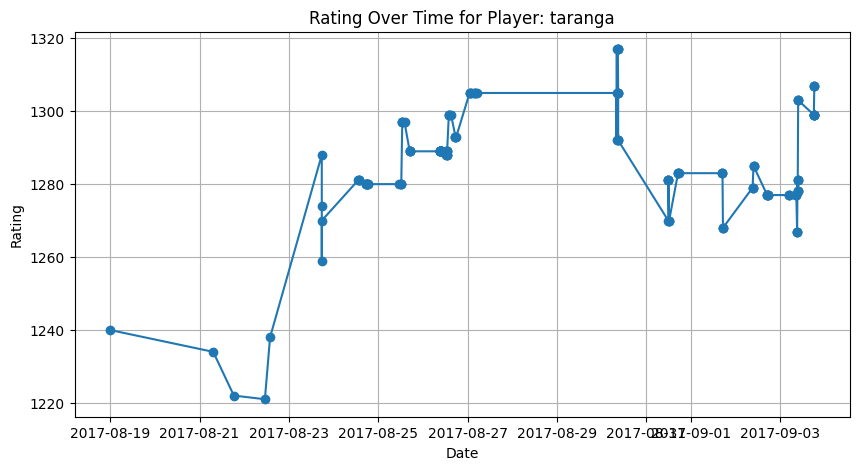

In [17]:
sample_player = rating_changes['player_id'].value_counts().idxmax()
player_data = all_games[all_games['player_id'] == sample_player]

plt.figure(figsize=(10,5))
plt.plot(player_data['date'], player_data['rating'], marker='o')
plt.title(f"Rating Over Time for Player: {sample_player}")
plt.xlabel("Date")
plt.ylabel("Rating")
plt.grid(True)
plt.show()
